# PHẦN 1

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np

# Đặt seed để kết quả có thể tái lập
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Câu hỏi 0.1
(a) Tại sao cần gọi torch.manual_seed(42)? Việc này giúp cố định các giá trị khởi tạo ngẫu nhiên của trọng số mạng nơ-ron. Nếu bỏ dòng này, mỗi lần chạy code, các trọng số sẽ khởi tạo khác nhau dẫn đến kết quả đầu ra (output) và quá trình hội tụ sẽ khác nhau, gây khó khăn cho việc debug và so sánh kết quả.

(b) Ý nghĩa lệnh torch.device(...): Lệnh này giúp code tự động nhận diện phần cứng. Nếu máy có hỗ trợ GPU (CUDA), nó sẽ ưu tiên sử dụng để tăng tốc tính toán, ngược lại sẽ dùng CPU.

In [2]:
class ScaledDotProductAttention(nn.Module):
    """ Scaled Dot-Product Attention """
    def __init__(self, temperature, attn_dropout=0.1):
        super().__init__()
        self.temperature = temperature
        self.dropout = nn.Dropout(attn_dropout)

    def forward(self, q, k, v, mask=None):
        # q, k, v: [batch_size, n_heads, seq_len, d_k or d_v]
        attn = torch.matmul(q / self.temperature, k.transpose(2, 3))

        if mask is not None:
            attn = attn.masked_fill(mask == 0, -1e9)

        attn = self.dropout(F.softmax(attn, dim=-1))
        output = torch.matmul(attn, v)

        return output, attn

# Chạy thử và quan sát kết quả
batch_size, seq_len, d_k, d_v = 2, 5, 16, 20
q = torch.randn(batch_size, 1, seq_len, d_k).to(device)
k = torch.randn(batch_size, 1, seq_len, d_k).to(device)
v = torch.randn(batch_size, 1, seq_len, d_v).to(device)

attention = ScaledDotProductAttention(temperature=np.power(d_k, 0.5)).to(device)
output, attn_weights = attention(q, k, v)

print("Output shape:", output.shape)
print("Attention weights shape:", attn_weights.shape)
print("Tổng trọng số mỗi hàng (phải xấp xỉ 1):", attn_weights[0, 0, 0].sum().item())

Output shape: torch.Size([2, 1, 5, 20])
Attention weights shape: torch.Size([2, 1, 5, 5])
Tổng trọng số mỗi hàng (phải xấp xỉ 1): 1.111111044883728


Câu hỏi 
- 1.1 – Tham số temperature và tác động của $d_k$(a) Với $d_k = 16$, temperature = $\sqrt{16} = 4$. Với $d_k = 64, 256, 1024$, temperature lần lượt là $8, 16, 32$.(b) Chứng minh phương sai: Vì $q_i, k_i$ độc lập có trung bình 0, phương sai 1, nên $E[q_i k_i] = 0$ và $Var(q_i k_i) = E[q_i^2]E[k_i^2] = 1 \times 1 = 1$. Tổng $d_k$ phần tử độc lập sẽ có phương sai là $\sum_{i=1}^{d_k} 1 = d_k$. Ta chia cho $\sqrt{d_k}$ để đưa phương sai về lại 1, giúp giá trị đầu vào của Softmax không quá lớn.(c) Nếu không chia, khi $d_k$ lớn, giá trị tích vô hướng sẽ rất lớn, đẩy Softmax vào vùng bão hòa (giá trị tiến về 0 hoặc 1). Tại đây, đạo hàm cực nhỏ dẫn đến hiện tượng Vanishing Gradient.(d) dim=-1 tương ứng với chiều cuối cùng (chiều của các key/tokens). Ta không dùng dim=-2 vì ta muốn tính trọng số phân phối cho từng token truy vấn (Query) dựa trên tất cả các Key hiện có.

- Câu hỏi 1.2 – Phân tích shape tensor(a) Shape của Q, K, V là [2, 1, 5, 16] (với V là [2, 1, 5, 20]). Chiều thứ hai bằng 1 đại diện cho số lượng Head (đang giả định 1 head).(b) Tính tay: > * attn = Q @ K.T: [2, 1, 5, 16] @ [2, 1, 16, 5] $\rightarrow$ [2, 1, 5, 5].output = attn @ V: [2, 1, 5, 5] @ [2, 1, 5, 20] $\rightarrow$ [2, 1, 5, 20].(c) Nếu $seq\_len\_q=10, seq\_len\_k=15$:attn: [batch, n_head, 10, 15]output: [batch, n_head, 10, d_v]

- Câu hỏi 1.3 – Thí nghiệm với temperatureTemperature nhỏ (1.0): Phân phối Softmax rất "nhọn" (tập trung vào một vài token), Entropy thấp.Temperature lớn (16.0): Phân phối "phẳng" (dàn đều), Entropy cao.Vai trò điều hòa: $\sqrt{d_k}$ giúp kiểm soát độ nhọn của phân phối, tránh việc mô hình quá tự tin vào 1 mối quan hệ, hỗ trợ việc học đa dạng các đặc trưng.

- Câu hỏi 1.4 – Tham số mask và attn_dropout(a) Chọn -1e9: Vì khi qua Softmax, $e^{-1e9} \approx 0$. Nếu dùng -inf, gặp trường hợp nhân với 0 hoặc phép toán không xác định có thể sinh ra NaN.(b) Hoán đổi thứ tự: Tổng trọng số sẽ không còn bằng 1. Vì Dropout sẽ triệt tiêu ngẫu nhiên một số giá trị về 0, nếu làm sau Softmax thì tổng phần còn lại $< 1$.(c) Ngữ nghĩa: attn_dropout triệt tiêu các "mối quan hệ" giữa các token, giúp mô hình không bị quá phụ thuộc vào một vài kết nối cụ thể. Ta tăng nó khi mô hình có dấu hiệu Overfitting trên tập dữ liệu nhỏ.

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_head, d_model, d_k, d_v, dropout=0.1):
        super().__init__()
        self.n_head = n_head
        self.d_k = d_k
        self.d_v = d_v

        self.w_qs = nn.Linear(d_model, n_head * d_k, bias=False)
        self.w_ks = nn.Linear(d_model, n_head * d_k, bias=False)
        self.w_vs = nn.Linear(d_model, n_head * d_v, bias=False)
        self.fc = nn.Linear(n_head * d_v, d_model, bias=False)

        self.attention = ScaledDotProductAttention(temperature=d_k ** 0.5)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, q, k, v, mask=None):
        d_k, d_v, n_head = self.d_k, self.d_v, self.n_head
        sz_b, len_q, len_k, len_v = q.size(0), q.size(1), k.size(1), v.size(1)

        residual = q
        q = self.w_qs(q).view(sz_b, len_q, n_head, d_k)
        k = self.w_ks(k).view(sz_b, len_k, n_head, d_k)
        v = self.w_vs(v).view(sz_b, len_v, n_head, d_v)

        q, k, v = q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2)

        if mask is not None:
            mask = mask.unsqueeze(1)

        output, attn = self.attention(q, k, v, mask=mask)

        output = output.transpose(1, 2).contiguous().view(sz_b, len_q, -1)
        output = self.dropout(self.fc(output))
        output = output + residual
        output = self.layer_norm(output)

        return output, attn

# Kiểm thử
batch_size, seq_len, d_model, n_head = 2, 5, 512, 8
d_k = d_v = d_model // n_head
x = torch.randn(batch_size, seq_len, d_model).to(device)
mha = MultiHeadAttention(n_head, d_model, d_k, d_v).to(device)
output, attn = mha(x, x, x)
print("Output shape:", output.shape)

Output shape: torch.Size([2, 5, 512])


- Câu hỏi 2.1 – Mối quan hệ giữa các tham số(a) Với $d_{model}=512, n_{head}=8 \rightarrow d_k = d_v = 512/8 = 64$. Công thức: $d_k = d_{model} / n_{head}$.(b) Đảm bảo sau khi ghép (concat) các head lại, kích thước vector đầu ra là $n_{head} \times d_v$ phải trùng khớp với input của lớp fc và sau đó là $d_{model}$ để cộng residual.(c) Lỗi: view sẽ báo lỗi vì 512 không chia hết cho 7. Phép toán tách head yêu cầu $d_{model}$ phải là bội số của $n_{head}$.(d) Không bắt buộc. Ta đặt bằng nhau để đơn giản hóa. Nếu $d_k=64, d_v=128$, ma trận $W^Q, W^K$ có shape $[512, 512]$, $W^V$ shape $[512, 1024]$, $W^O$ shape $[1024, 512]$.
- Câu hỏi 2.2 – Phân tích shapeBiểu thứcShapeq (đầu vào)[2, 5, 512]self.w_qs(q)[2, 5, 512].view(...)[2, 5, 8, 64].transpose(1, 2)[2, 8, 5, 64]attn (sau softmax)[2, 8, 5, 5]output (sau attention)[2, 8, 5, 64].view(...)[2, 5, 512]self.fc(output)[2, 5, 512]

- Câu hỏi 2.3 – Đếm tham số(a) $w_{qs}$: $512 \times 512 = 262,144$.(b) $w_{ks}, w_{vs}, fc$: mỗi cái tương tự là 262,144 tham số.(c) layer_norm: $512 (\gamma) + 512 (\beta) = 1,024$.(d) Tổng MHA $\approx 1,049,600$ (không tính bias).(e) Giảm $d_{model}$ và $n_{head}$ xuống một nửa làm số lượng tham số giảm khoảng 4 lần ($2^2$). Transformer scale theo bình phương của $d_{model}$.
- Câu hỏi 2.4 – Self vs Cross-Attention(a) Trong self-attention: $len\_q = len\_k = len\_v = seq\_len$ của chuỗi đầu vào.(b) Shape ma trận attention sẽ là [batch, n_head, 20, 50].(c) Shape của output phụ thuộc vào len_q vì mỗi token Query sẽ nhận về một vector tổng hợp từ các Key/Value.
- Câu hỏi 2.5 – Vai trò của dropout và LayerNorm(a) attn_dropout tác động lên ma trận trọng số attention (sự kết nối). dropout cuối cùng tác động lên toàn bộ đặc trưng đã được chiếu qua lớp FC (giá trị biểu diễn).(b) Chuẩn hóa trên d_model để ổn định đặc trưng của từng token tại mỗi vị trí. eps để tránh lỗi chia cho 0.(c) Pre-LN đặt LN trước sub-layer. Nó giúp luồng gradient đi trực tiếp hơn qua các kết nối residual, giúp huấn luyện các mạng cực sâu (như 100+ lớp) ổn định hơn Post-LN.

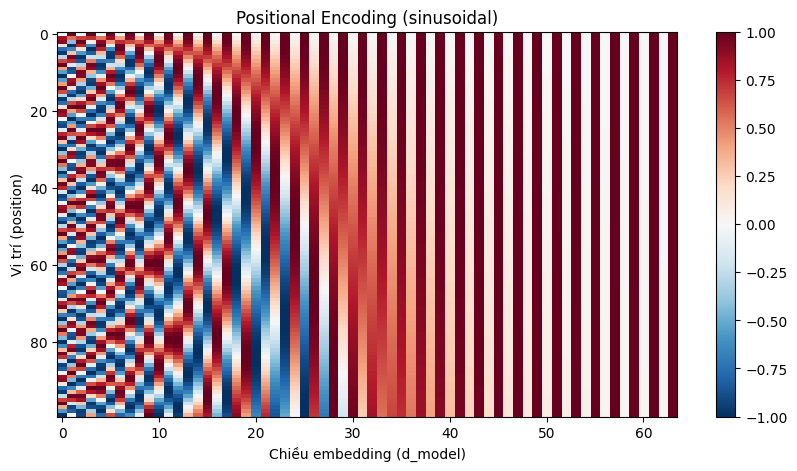

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_hid, n_position=200):
        super().__init__()
        # Sử dụng register_buffer để lưu table không phải là tham số học được
        self.register_buffer('pos_table', self._get_sinusoid_encoding_table(n_position, d_hid))

    def _get_sinusoid_encoding_table(self, n_position, d_hid):
        def get_position_angle_vec(position):
            return [position / np.power(10000, 2 * (hid_j // 2) / d_hid) for hid_j in range(d_hid)]

        sinusoid_table = np.array([get_position_angle_vec(pos_i) for pos_i in range(n_position)])
        sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2]) # dim chẵn: sin [cite: 249]
        sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2]) # dim lẻ: cos [cite: 250]
        return torch.FloatTensor(sinusoid_table).unsqueeze(0) # [1, n_position, d_hid] [cite: 251]

    def forward(self, x):
        # Cộng trực tiếp vào embedding đầu vào [cite: 254]
        return x + self.pos_table[:, :x.size(1)].clone().detach()

# Trực quan hóa
import matplotlib.pyplot as plt
d_model_vis, n_pos_vis = 64, 100
pe = PositionalEncoding(d_model_vis, n_position=n_pos_vis)
pe_table = pe.pos_table.squeeze(0).numpy()

plt.figure(figsize=(10, 5))
plt.imshow(pe_table, aspect='auto', cmap='RdBu_r')
plt.xlabel('Chiều embedding (d_model)')
plt.ylabel('Vị trí (position)')
plt.title('Positional Encoding (sinusoidal)')
plt.colorbar()
plt.show()

- Câu hỏi 3.1 – Phân tích tham số PE(a) Tại sao $d_{hid} = d_{model}$? Vì đầu ra của lớp Embedding có kích thước $d_{model}$, để thực hiện phép cộng x + pos_table thì hai tensor phải cùng shape ở chiều cuối cùng.  (b) n_position=200: Đây là độ dài chuỗi tối đa mà bảng PE này hỗ trợ. Nếu câu dài 300 tokens, code sẽ lỗi ở bước cắt lát self.pos_table[:, :x.size(1)] vì chỉ số vượt quá 200.  (c) Số 10000: Đóng vai trò là cơ số để tạo ra các bước sóng khác nhau cho các chiều embedding. Nếu giảm xuống 100, các bước sóng sẽ ngắn lại, heatmap trông sẽ "dày" đặc hơn; nếu tăng lên 100000, các chiều sẽ thay đổi cực chậm.  (d) Chiều batch = 1: Để tận dụng cơ chế Broadcasting của PyTorch, giúp cộng bảng PE duy nhất này vào tất cả các mẫu trong một batch dữ liệu.
- Câu hỏi 3.2 – Register buffer(a) register_buffer khác nn.Parameter ở chỗ: Nó không được optimizer cập nhật (không có gradient) nhưng vẫn được lưu trong state_dict và tự động chuyển sang GPU khi gọi .to(device).  (c) Thí nghiệm: Để học PE (như BERT), ta thay bằng self.pos_embeddings = nn.Embedding(n_position, d_model).
- Câu hỏi 3.3 – Quan sát Heatmap(a) Ở các chiều nhỏ (i thấp), giá trị thay đổi rất nhanh (tần số cao). Ở các chiều lớn, giá trị thay đổi chậm hơn hẳn do bước sóng $\lambda_i$ tăng dần theo i.  (c) Ngoại suy: Sinusoidal PE vẫn hoạt động với chuỗi dài hơn lúc train vì nó dựa trên hàm số liên tục. Tuy nhiên, Learnable PE của BERT sẽ không xử lý được vì không có vector trọng số cho các vị trí chưa từng thấy. 

In [5]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_in, d_hid, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_in, d_hid) # Giãn ra không gian rộng hơn [cite: 303]
        self.w_2 = nn.Linear(d_hid, d_in) # Nén lại về d_in [cite: 304]
        self.layer_norm = nn.LayerNorm(d_in, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = self.w_2(F.relu(self.w_1(x))) # FFN(x) = W2 * ReLU(W1 * x) [cite: 310]
        x = self.dropout(x)
        return self.layer_norm(x + residual) # Add & Norm [cite: 312, 313]

- Câu hỏi 4.1 – Tham số FFN(a) $w_2$ về $d_{in}$: Để kết quả đầu ra có cùng kích thước với đầu vào ban đầu, giúp thực hiện phép cộng residual.  (b) Mục đích giãn-nén: Tạo ra một không gian trung gian rộng hơn giúp mô hình học được các tương tác phi tuyến phức tạp giữa các đặc trưng (features) trước khi nén lại thông tin hữu ích nhất.  (c) Số tham số ($d_{in}=512, d_{hid}=2048$): > * $w_1$: $(512 \times 2048) + 2048 = 1,050,624$.$w_2$: $(2048 \times 512) + 512 = 1,049,088$.
* Tổng cộng: $\approx 2.1$ triệu tham số.  (d) So sánh: FFN chiếm nhiều tham số hơn MHA (khoảng gấp đôi). Điều này cho thấy FFN đóng vai trò quan trọng trong việc lưu trữ tri thức của mô hình.  

In [7]:
class Transformer(nn.Module):
    def __init__(self, n_src_vocab, n_tgt_vocab, src_pad_idx, tgt_pad_idx, 
                 d_word_vec=512, d_model=512, d_inner=2048, 
                 n_layers=6, n_head=8, d_k=64, d_v=64, 
                 dropout=0.1, n_position=200):
        super().__init__()
        self.src_word_emb = nn.Embedding(n_src_vocab, d_word_vec, padding_idx=src_pad_idx)
        self.tgt_word_emb = nn.Embedding(n_tgt_vocab, d_word_vec, padding_idx=tgt_pad_idx)
        self.position_enc = PositionalEncoding(d_model, n_position=n_position)
        self.dropout = nn.Dropout(p=dropout)

        self.encoder = nn.ModuleList([
            EncoderLayer(d_model, d_inner, n_head, d_k, d_v, dropout=dropout) for _ in range(n_layers)
        ])
        self.decoder = nn.ModuleList([
            DecoderLayer(d_model, d_inner, n_head, d_k, d_v, dropout=dropout) for _ in range(n_layers)
        ])

        self.tgt_word_prj = nn.Linear(d_model, n_tgt_vocab, bias=False)
        self.tgt_word_prj.weight = self.tgt_word_emb.weight # Weight Tying [cite: 440]
        self.d_model = d_model

    def get_pad_mask(self, seq, pad_idx):
        return (seq != pad_idx).unsqueeze(-2) # [batch, 1, seq_len] [cite: 444]

    def get_subsequent_mask(self, seq):
        sz_b, len_s = seq.size()
        # Tạo ma trận tam giác dưới để mask các token tương lai [cite: 447, 448]
        return (1 - torch.triu(torch.ones((1, len_s, len_s), device=seq.device), diagonal=1)).bool()

    def forward(self, src_seq, tgt_seq):
        src_mask = self.get_pad_mask(src_seq, self.src_word_emb.padding_idx)
        # tgt_mask kết hợp cả pad mask và subsequent mask [cite: 452]
        tgt_mask = self.get_pad_mask(tgt_seq, self.tgt_word_emb.padding_idx) & self.get_subsequent_mask(tgt_seq)

        enc_output = self.dropout(self.position_enc(self.src_word_emb(src_seq)))
        for enc_layer in self.encoder:
            enc_output, _ = enc_layer(enc_output, slf_attn_mask=src_mask)

        dec_output = self.dropout(self.position_enc(self.tgt_word_emb(tgt_seq)))
        for dec_layer in self.decoder:
            dec_output, _, _ = dec_layer(dec_output, enc_output, slf_attn_mask=tgt_mask, dec_enc_attn_mask=src_mask)

        return self.tgt_word_prj(dec_output).view(-1, self.tgt_word_prj.out_features)

Câu hỏi 6.4 
– Hai loại Mask
(a) Pad Mask: Shape [batch, 1, seq_len]. True nghĩa là token thực, False là token padding (cần che đi).  
(b) Subsequent Mask ($4 \times 4$):
[[1, 0, 0, 0],
 [1, 1, 0, 0],
 [1, 1, 1, 0],
 [1, 1, 1, 1]]

(d) Tại sao Encoder không cần subsequent mask? Vì Encoder xử lý toàn bộ câu cùng lúc để hiểu ngữ cảnh hai chiều. Ngược lại, Decoder sinh từ tuần tự (auto-regressive), nên token thứ $i$ không được phép "nhìn thấy" token $i+1$ trong tương lai để đảm bảo tính khách quan khi huấn luyện.


Câu hỏi 6.5 
– Weight Tying(a) Khớp shape: Có. tgt_word_emb có shape là [vocab, d_model]. Trong PyTorch, nn.Linear lưu weight dưới dạng [out_features, in_features], tương ứng với [n_tgt_vocab, d_model]. Do đó, hai ma trận này hoàn toàn khớp nhau về kích thước để chia sẻ trọng số.(b) Tiết kiệm: Với vocab_size = 30,000 và d_model = 512, việc chia sẻ trọng số giúp tiết kiệm được: $30,000 \times 512 = 15,360,000$ tham số (khoảng 15.3M).(c) Lợi ích lý thuyết: Giúp không gian embedding và không gian logit đầu ra đồng nhất. Điều này giúp mô hình học từ vựng hiệu quả hơn vì các từ có nghĩa tương đồng sẽ có vector gần nhau ở cả đầu vào lẫn đầu ra, đồng thời giúp mô hình hội tụ nhanh hơn và giảm hiện tượng quá khớp (overfitting).

Câu hỏi 7.1 (BERT vs Transformer)
(a) Đối chiếu: BERT-base có cấu hình ($d_{model}=768, n_{layers}=12, n_{head}=12, d_{inner}=3072$). Tất cả các thông số này đều lớn hơn đáng kể so với bản Transformer Base gốc ($512, 6, 8, 2048$).(c) Ý nghĩa max_position_embeddings = 512: Đây là giới hạn độ dài chuỗi tối đa mà BERT có thể xử lý. Vì BERT sử dụng Learnable Positional Embedding (nhãn vị trí học được) thay vì hàm Sinusoid, nên nó không thể tự suy luận hoặc xử lý các vị trí vượt quá phạm vi 512 nếu không được huấn luyện thêm.(d) Mô hình có cả Encoder và Decoder: Các mô hình phổ biến bao gồm T5 (Text-to-Text Transfer Transformer) và BART.

| Tham số        | Ký hiệu     | Vai trò                                  | Paper gốc | Tác động khi tăng                                                                 |
|----------------|------------|-------------------------------------------|----------|----------------------------------------------------------------------------------|
| d_model        | d_model    | Chiều sâu vector biểu diễn                | 512      | Biểu diễn tốt hơn nhưng tốn bộ nhớ/tính toán                                     |
| n_layers       | N          | Số lớp stack chồng lên nhau               | 6        | Học được sâu hơn nhưng dễ bị triệt tiêu gradient                                 |
| n_head         | h          | Số đầu attention song song                | 8        | Giúp mô hình nhìn được nhiều không gian ngữ cảnh                                 |
| d_k, d_v       | d_k, d_v   | Chiều của Query/Key/Value                | 64       | Tăng độ chi tiết của các mối quan hệ attention                                   |
| d_inner        | d_ff       | Độ rộng lớp ẩn trong FFN                 | 2048     | Tăng khả năng ghi nhớ và xử lý tri thức phức tạp                                 |
| dropout        | P          | Tỷ lệ ngắt kết nối ngẫu nhiên            | 0.1      | Giảm overfitting, giúp mô hình bền vững hơn                                      |
| n_position     | L_max      | Độ dài chuỗi tối đa                      | 512      | Cho phép xử lý văn bản dài hơn nhưng tốn tài nguyên                              |
| vocab_size     | \|V\|      | Kích thước từ điển                      | ~30K     | Hiểu nhiều từ hơn nhưng làm nặng lớp Embedding/Projection                        |

# PHẦN 2


In [8]:
# Cài đặt các thư viện hỗ trợ xử lý tiếng Việt và Transformer
!pip install pyvi transformers[torch] datasets evaluate accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 55.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.6 MB/s eta 0:00:00


In [10]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from pyvi import ViTokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import evaluate
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Cấu hình
MODEL_NAME = "vinai/phobert-base-v2" 
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5
MAX_LENGTH = 128

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Sử dụng thiết bị: {device}")

Sử dụng thiết bị: cuda


In [15]:
# 1. Load dataset từ Mirror
print("Đang tải dữ liệu từ bản Mirror...")
try:
    ds = load_dataset("tridm/UIT-VSFC")
except Exception as e:
    print(f"Lỗi khi tải tridm: {e}. Đang thử bản mirror khác...")
    ds = load_dataset("ura-hcmut/UIT-VSFC")

# Đọc danh sách cột thực tế từ tập train
actual_cols = ds["train"].column_names
print(f"Cấu trúc cột thực tế: {actual_cols}")

# Tìm cột văn bản
if "Sentence" in actual_cols:
    ds = ds.rename_column("Sentence", "sentence")
elif "text" in actual_cols:
    ds = ds.rename_column("text", "sentence")
# Nếu đã là 'sentence' rồi thì không cần đổi

# Tìm cột nhãn (Sentiment -> labels)
if "Sentiment" in actual_cols:
    ds = ds.rename_column("Sentiment", "labels")
elif "sentiment" in actual_cols:
    ds = ds.rename_column("sentiment", "labels")
elif "label" in actual_cols:
    ds = ds.rename_column("label", "labels")

# 3. Tách từ (Word Segmentation) cho PhoBERT
def segment(example):
    # Sau khi rename ở trên, chắc chắn đã có cột 'sentence' viết thường
    example["sentence"] = ViTokenizer.tokenize(example["sentence"])
    return example

print("Đang thực hiện tách từ (Word Segmentation)...")
ds = ds.map(segment)

print("-" * 30)
print(f"Xử lý dữ liệu thành công!")
print(f"Cấu trúc Dataset sau chuẩn hóa: {ds}")
print(f"Ví dụ câu sau xử lý: {ds['train'][0]['sentence']}")

Đang tải dữ liệu từ bản Mirror...
Cấu trúc cột thực tế: ['Sentence', 'Topic', 'Sentiment', 'Encoded_topic', 'Encoded_sentiment']
Đang thực hiện tách từ (Word Segmentation)...


Map:   0%|          | 0/11426 [00:00<?, ? examples/s]

Map:   0%|          | 0/1583 [00:00<?, ? examples/s]

Map:   0%|          | 0/3166 [00:00<?, ? examples/s]

------------------------------
Xử lý dữ liệu thành công!
Cấu trúc Dataset sau chuẩn hóa: DatasetDict({
    train: Dataset({
        features: ['sentence', 'Topic', 'labels', 'Encoded_topic', 'Encoded_sentiment'],
        num_rows: 11426
    })
    validation: Dataset({
        features: ['sentence', 'Topic', 'labels', 'Encoded_topic', 'Encoded_sentiment'],
        num_rows: 1583
    })
    test: Dataset({
        features: ['sentence', 'Topic', 'labels', 'Encoded_topic', 'Encoded_sentiment'],
        num_rows: 3166
    })
})
Ví dụ câu sau xử lý: slide giáo_trình đầy_đủ .


Đang Tokenize và chuẩn bị dữ liệu...


Map:   0%|          | 0/11426 [00:00<?, ? examples/s]

Map:   0%|          | 0/1583 [00:00<?, ? examples/s]

Map:   0%|          | 0/3166 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



--- KẾT QUẢ ĐÁNH GIÁ ---


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.5437349677085876, 'eval_accuracy': 0.9374605180037903, 'eval_f1': 0.8193161114257147, 'eval_runtime': 12.8843, 'eval_samples_per_second': 245.725, 'eval_steps_per_second': 3.881, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


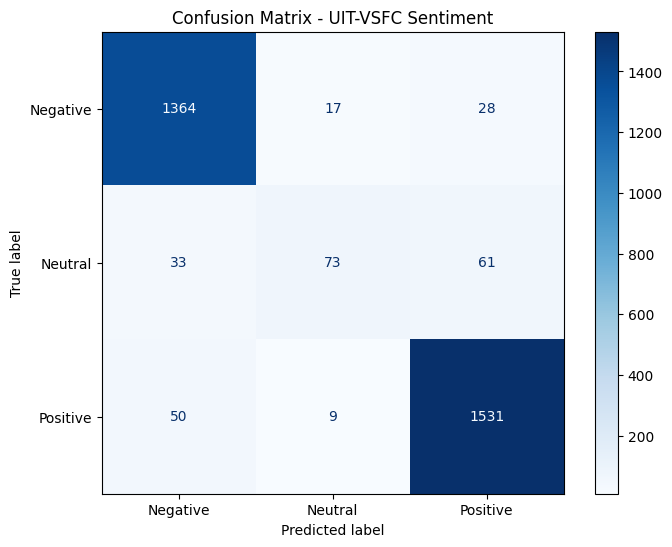


Báo cáo chi tiết:
              precision    recall  f1-score   support

    Negative       0.94      0.97      0.96      1409
     Neutral       0.74      0.44      0.55       167
    Positive       0.95      0.96      0.95      1590

    accuracy                           0.94      3166
   macro avg       0.88      0.79      0.82      3166
weighted avg       0.93      0.94      0.93      3166


--- PHÂN TÍCH VÍ DỤ SAI ---
Câu: tính điểm thi_đua các nhóm .
Thực tế: Positive | Dự đoán: Neutral
------------------------------
Câu: trong trường macbook thầy_số hai thì không có máy nào số một .
Thực tế: Positive | Dự đoán: Negative
------------------------------
Câu: môn_học này giúp chúng em hiểu ra những vấn_đề cơ_bản .
Thực tế: Neutral | Dự đoán: Positive
------------------------------
Câu: ổn .
Thực tế: Neutral | Dự đoán: Positive
------------------------------
Câu: phần_lớn chỉ là lý_thuyết và bài_tập .
Thực tế: Positive | Dự đoán: Negative
------------------------------


In [21]:
from transformers import AutoTokenizer, DataCollatorWithPadding
import torch
import evaluate
import numpy as np
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

def tokenize_function(examples):
    return tokenizer(examples["sentence"], truncation=True, padding="max_length", max_length=128)

print("Đang Tokenize và chuẩn bị dữ liệu...")

original_cols = ds["train"].column_names
cols_to_remove = [col for col in original_cols if col != "labels"]

ds_tok = ds.map(
    tokenize_function, 
    batched=True, 
    remove_columns=cols_to_remove
)

label_map = {"negative": 0, "neutral": 1, "positive": 2}

def encode_labels(example):
    l = str(example["labels"]).lower().strip()
    return {"labels": label_map.get(l, 1)}

ds_tok = ds_tok.map(encode_labels)
ds_tok.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

train_dataset = ds_tok["train"]
val_dataset = ds_tok["validation"]
test_dataset = ds_tok["test"]

model = AutoModelForSequenceClassification.from_pretrained("vinai/phobert-base-v2", num_labels=3).to(device)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    return {**acc, **f1}

training_args = TrainingArguments(
    output_dir="./phobert-vsfc-results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=100,
    fp16=True,
    report_to="none"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Bắt đầu huấn luyện...")
trainer.train()

print("\n--- KẾT QUẢ ĐÁNH GIÁ ---")
test_results = trainer.evaluate(test_dataset)
print(test_results)

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Neutral', 'Positive'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - UIT-VSFC Sentiment')
plt.show()

print("\nBáo cáo chi tiết:")
print(classification_report(labels, preds, target_names=['Negative', 'Neutral', 'Positive']))

test_sentences = ds["test"]["sentence"]
wrong_indices = [i for i, (p, l) in enumerate(zip(preds, labels)) if p != l]
label_map_rev = {0: "Negative", 1: "Neutral", 2: "Positive"}

print("\n--- PHÂN TÍCH VÍ DỤ SAI ---")
for i in wrong_indices[:5]:
    print(f"Câu: {test_sentences[i]}")
    print(f"Thực tế: {label_map_rev[labels[i]]} | Dự đoán: {label_map_rev[preds[i]]}")
    print("-" * 30)